In [17]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

OUTPUT_DIR = Path("uc4_medication_aware_micropriority_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\jaymo\Desktop\Desktop\HTA_Internship\USE_CASE_4\uc4_medication_aware_micropriority_outputs


In [19]:
SAFETY_STATEMENT = """
UC4 Medication-Aware Micro-Priority Prototype

This notebook is a synthetic/offline prototype. It does not diagnose medication side effects,
does not infer medication causality, and does not recommend medication changes.

Medication-aware priorities are generated from:
- structured caregiver observation codes,
- medication watch-area codes,
- timing/recurrence rules,
- care-plan/profile context.

The SLM-like output in this notebook is deterministic template text only.
"""

print(SAFETY_STATEMENT)


UC4 Medication-Aware Micro-Priority Prototype

This notebook is a synthetic/offline prototype. It does not diagnose medication side effects,
does not infer medication causality, and does not recommend medication changes.

Medication-aware priorities are generated from:
- structured caregiver observation codes,
- medication watch-area codes,
- timing/recurrence rules,
- care-plan/profile context.

The SLM-like output in this notebook is deterministic template text only.



In [21]:
patient_profile = {
    "patient_id": "Mike_DEMO_001",
    "display_name": "Mike",
    "age": 24,
    "primary_context": "Cerebral palsy with high support needs",
    "mobility_support_level": "high",
    "positioning_support_needed": True,
    "communication_context": "Caregiver observes nonverbal discomfort cues",
    "care_plan_priorities": [
        "mobility_transfers",
        "positioning_support",
        "pain_behavior_tracking",
        "medication_adherence",
        "skin_pressure_risk",
        "sleep_recovery"
    ],
    "safety_note": "Synthetic demo profile for UC4 prototype; not real PHI."
}

with open(OUTPUT_DIR / "synthetic_patient_profile.json", "w") as f:
    json.dump(patient_profile, f, indent=2)

patient_profile

{'patient_id': 'Mike_DEMO_001',
 'display_name': 'Mike',
 'age': 24,
 'primary_context': 'Cerebral palsy with high support needs',
 'mobility_support_level': 'high',
 'positioning_support_needed': True,
 'communication_context': 'Caregiver observes nonverbal discomfort cues',
 'care_plan_priorities': ['mobility_transfers',
  'positioning_support',
  'pain_behavior_tracking',
  'medication_adherence',
  'skin_pressure_risk',
  'sleep_recovery'],
 'safety_note': 'Synthetic demo profile for UC4 prototype; not real PHI.'}

In [9]:
OBSERVATION_CODES = [
    "LOOKS_NORMAL",
    "NOT_SURE",
    "DEVICE_OR_SENSOR_ISSUE",

    "RECENT_ACTIVITY_OR_EXERTION",
    "LOW_MOVEMENT",
    "TRANSFER_OR_POSITIONING_CONTEXT",

    "PAIN_OR_DISCOMFORT",
    "UNUSUAL_FATIGUE",
    "POOR_SLEEP_OR_RESTLESSNESS",

    "BREATHING_CONCERN",
    "COLOR_OR_OXYGEN_CONCERN",

    "MISSED_OR_DELAYED_MEDICATION",
    "RECENT_MEDICATION_CHANGE",
    "APPETITE_OR_HYDRATION_CHANGE",

    "BOWEL_OR_BLADDER_CHANGE",
    "SKIN_OR_PRESSURE_CONCERN",

    "SEIZURE_LIKE_EVENT_REPORTED",
    "UNUSUAL_RESPONSIVENESS",

    "CAREGIVER_WANTS_PROVIDER_REVIEW"
]

CONTEXT_CODES = [
    "DURING_TRANSFER",
    "WHILE_SITTING_OR_POSITIONED",
    "AFTER_ACTIVITY_OR_THERAPY",
    "AROUND_MEDICATION_TIME",
    "DURING_SLEEP_OR_NIGHT",
    "MEAL_OR_HYDRATION_RELATED",
    "BATHROOM_OR_BOWEL_BLADDER",
    "UNKNOWN_OR_NOT_SURE"
]

MEDICATION_CONCERN_CODES = [
    "SLEEPINESS_FATIGUE",
    "DIZZINESS_OR_LIGHTHEADEDNESS",
    "WEAKNESS_OR_LOW_TONE_CONCERN",
    "MOOD_BEHAVIOR_CHANGE",
    "APPETITE_OR_HYDRATION_CHANGE",
    "BOWEL_CHANGE",
    "BREATHING_CONCERN",
    "HEART_RATE_OR_BP_CONCERN",
    "SKIN_RASH_OR_ALLERGY_CONCERN",
    "MISSED_OR_DELAYED_DOSE",
    "MEDICATION_TIMING_CONTEXT_NEEDED"
]

print("Observation codes:", len(OBSERVATION_CODES))
print("Context codes:", len(CONTEXT_CODES))
print("Medication concern codes:", len(MEDICATION_CONCERN_CODES))

,patient_id,medication_name,medication_class,scheduled_times,source,active
0,Mike_DEMO_001,Tone Medication A,tone_spasticity_related,"[08:00, 14:00, 20:00]",synthetic_demo,True
1,Mike_DEMO_001,Seizure Medication B,anti_seizure_related,"[08:00, 20:00]",synthetic_demo,True
2,Mike_DEMO_001,Bowel Routine Medication C,bowel_regimen_related,[18:00],synthetic_demo,True


In [23]:
medication_profile = pd.DataFrame([
    {
        "medication_id": "med_demo_001",
        "display_name": "Medication A",
        "medication_class": "tone/spasticity-related medication",
        "scheduled_times": ["08:00", "14:00", "21:00"],
        "source": "synthetic_demo",
        "clinician_reviewed": False
    },
    {
        "medication_id": "med_demo_002",
        "display_name": "Medication B",
        "medication_class": "seizure-related medication",
        "scheduled_times": ["09:00", "21:00"],
        "source": "synthetic_demo",
        "clinician_reviewed": False
    },
    {
        "medication_id": "med_demo_003",
        "display_name": "Medication C",
        "medication_class": "bowel regimen",
        "scheduled_times": ["20:00"],
        "source": "synthetic_demo",
        "clinician_reviewed": False
    }
])

medication_profile.to_csv(OUTPUT_DIR / "synthetic_medication_profile.csv", index=False)
medication_profile

,medication_id,display_name,medication_class,scheduled_times,source,clinician_reviewed
0,med_demo_001,Medication A,tone/spasticity-related medication,"[08:00, 14:00, 21:00]",synthetic_demo,False
1,med_demo_002,Medication B,seizure-related medication,"[09:00, 21:00]",synthetic_demo,False
2,med_demo_003,Medication C,bowel regimen,[20:00],synthetic_demo,False


In [25]:
medication_watch_table = pd.DataFrame([
    {
        "medication_class": "tone/spasticity-related medication",
        "watch_area_code": "SLEEPINESS_FATIGUE",
        "caregiver_label": "sleepiness or unusual tiredness",
        "severity_floor": 1,
        "caregiver_safe_note": "Track timing and whether it differs from baseline. Do not infer medication cause."
    },
    {
        "medication_class": "tone/spasticity-related medication",
        "watch_area_code": "WEAKNESS_OR_LOW_TONE_CONCERN",
        "caregiver_label": "more weakness or lower engagement than usual",
        "severity_floor": 1,
        "caregiver_safe_note": "Share persistent or worsening changes with the care team."
    },
    {
        "medication_class": "seizure-related medication",
        "watch_area_code": "SLEEPINESS_FATIGUE",
        "caregiver_label": "sleepiness or unusual tiredness",
        "severity_floor": 1,
        "caregiver_safe_note": "Track timing, recurrence, and missed/delayed doses."
    },
    {
        "medication_class": "seizure-related medication",
        "watch_area_code": "MOOD_BEHAVIOR_CHANGE",
        "caregiver_label": "new behavior or mood change",
        "severity_floor": 1,
        "caregiver_safe_note": "Track change from baseline and share with care team if persistent."
    },
    {
        "medication_class": "seizure-related medication",
        "watch_area_code": "MISSED_OR_DELAYED_DOSE",
        "caregiver_label": "missed or delayed dose context",
        "severity_floor": 1,
        "caregiver_safe_note": "Log missed/delayed dose; do not change dose without clinician guidance."
    },
    {
        "medication_class": "bowel regimen",
        "watch_area_code": "BOWEL_CHANGE",
        "caregiver_label": "bowel routine change",
        "severity_floor": 1,
        "caregiver_safe_note": "Track bowel routine, hydration, and discomfort timing."
    },
    {
        "medication_class": "bowel regimen",
        "watch_area_code": "APPETITE_OR_HYDRATION_CHANGE",
        "caregiver_label": "hydration or intake changes",
        "severity_floor": 1,
        "caregiver_safe_note": "Track intake context; do not infer medication cause."
    }
])

medication_watch_table.to_csv(OUTPUT_DIR / "local_medication_watch_area_table.csv", index=False)
medication_watch_table

,medication_class,watch_area_code,caregiver_label,severity_floor,caregiver_safe_note
0,tone/spasticity-related medication,SLEEPINESS_FATIGUE,sleepiness or unusual tiredness,1,Track timing and whether it differs from baseline. Do not infer medication cause.
1,tone/spasticity-related medication,WEAKNESS_OR_LOW_TONE_CONCERN,more weakness or lower engagement than usual,1,Share persistent or worsening changes with the care team.
2,seizure-related medication,SLEEPINESS_FATIGUE,sleepiness or unusual tiredness,1,"Track timing, recurrence, and missed/delayed doses."
3,seizure-related medication,MOOD_BEHAVIOR_CHANGE,new behavior or mood change,1,Track change from baseline and share with care team if persistent.
4,seizure-related medication,MISSED_OR_DELAYED_DOSE,missed or delayed dose context,1,Log missed/delayed dose; do not change dose without clinician guidance.
5,bowel regimen,BOWEL_CHANGE,bowel routine change,1,"Track bowel routine, hydration, and discomfort timing."
6,bowel regimen,APPETITE_OR_HYDRATION_CHANGE,hydration or intake changes,1,Track intake context; do not infer medication cause.


In [27]:
OBSERVATION_TO_MED_CONCERN_MAP = {
    "UNUSUAL_FATIGUE": ["SLEEPINESS_FATIGUE"],
    "POOR_SLEEP_OR_RESTLESSNESS": ["SLEEPINESS_FATIGUE", "MOOD_BEHAVIOR_CHANGE"],
    "BREATHING_CONCERN": ["BREATHING_CONCERN"],
    "APPETITE_OR_HYDRATION_CHANGE": ["APPETITE_OR_HYDRATION_CHANGE"],
    "BOWEL_OR_BLADDER_CHANGE": ["BOWEL_CHANGE"],
    "PAIN_OR_DISCOMFORT": ["MEDICATION_TIMING_CONTEXT_NEEDED"],
    "MISSED_OR_DELAYED_MEDICATION": ["MISSED_OR_DELAYED_DOSE"],
    "UNUSUAL_RESPONSIVENESS": ["SLEEPINESS_FATIGUE", "MOOD_BEHAVIOR_CHANGE"]
}

OBSERVATION_TO_MED_CONCERN_MAP

{'UNUSUAL_FATIGUE': ['SLEEPINESS_FATIGUE'],
 'POOR_SLEEP_OR_RESTLESSNESS': ['SLEEPINESS_FATIGUE', 'MOOD_BEHAVIOR_CHANGE'],
 'BREATHING_CONCERN': ['BREATHING_CONCERN'],
 'APPETITE_OR_HYDRATION_CHANGE': ['APPETITE_OR_HYDRATION_CHANGE'],
 'BOWEL_OR_BLADDER_CHANGE': ['BOWEL_CHANGE'],
 'PAIN_OR_DISCOMFORT': ['MEDICATION_TIMING_CONTEXT_NEEDED'],
 'MISSED_OR_DELAYED_MEDICATION': ['MISSED_OR_DELAYED_DOSE'],
 'UNUSUAL_RESPONSIVENESS': ['SLEEPINESS_FATIGUE', 'MOOD_BEHAVIOR_CHANGE']}

In [29]:
def parse_time_str(t):
    """Parse HH:MM into datetime.time."""
    hh, mm = t.split(":")
    return time(int(hh), int(mm))

def minutes_between_times(dt, scheduled_time_str):
    """
    Returns absolute minutes between datetime dt and scheduled time on same day.
    """
    sched_time = parse_time_str(scheduled_time_str)
    sched_dt = datetime.combine(dt.date(), sched_time)
    return abs((dt - sched_dt).total_seconds() / 60.0)

def min_minutes_to_med_window(event_dt, medication_profile):
    """
    Minimum minutes from event timestamp to any scheduled medication time.
    """
    mins = []
    for _, row in medication_profile.iterrows():
        for st in row["scheduled_times"]:
            mins.append(minutes_between_times(event_dt, st))
    return min(mins) if mins else np.inf

def is_near_med_window(event_dt, medication_profile, window_minutes=120):
    return min_minutes_to_med_window(event_dt, medication_profile) <= window_minutes

def get_patient_med_watch_areas(medication_profile, medication_watch_table):
    """
    Join medication profile to local med watch table by medication_class.
    """
    joined = medication_profile.merge(
        medication_watch_table,
        on="medication_class",
        how="left"
    )
    return joined

def count_code(events_df, code, days=None, anchor_date=None):
    df = events_df.copy()
    if days is not None and anchor_date is not None:
        cutoff = anchor_date - timedelta(days=days)
        df = df[df["timestamp_dt"] >= cutoff]
    return df["observation_codes"].apply(lambda codes: code in codes).sum()

def count_any_code(events_df, codes, days=None, anchor_date=None):
    df = events_df.copy()
    if days is not None and anchor_date is not None:
        cutoff = anchor_date - timedelta(days=days)
        df = df[df["timestamp_dt"] >= cutoff]
    return df["observation_codes"].apply(lambda xs: any(c in xs for c in codes)).sum()

def count_context(events_df, context, days=None, anchor_date=None):
    df = events_df.copy()
    if days is not None and anchor_date is not None:
        cutoff = anchor_date - timedelta(days=days)
        df = df[df["timestamp_dt"] >= cutoff]
    return df["context_codes"].apply(lambda codes: context in codes).sum()

def get_week_events(events_df, anchor_date, days=7):
    cutoff = anchor_date - timedelta(days=days)
    return events_df[events_df["timestamp_dt"] >= cutoff].copy()

In [32]:
anchor_date = datetime(2026, 7, 15, 18, 0, 0)

events_raw = [
    {
        "event_id": "evt_001",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-09T21:20:00",
        "source_use_case": "UC2",
        "source_event_type": "ML_ANOMALY",
        "severity": 1,
        "anomaly_type": "SLEEP_RECOVERY_DEVIATION",
        "observation_codes": ["POOR_SLEEP_OR_RESTLESSNESS", "UNUSUAL_FATIGUE"],
        "context_codes": ["DURING_SLEEP_OR_NIGHT"],
        "action_taken": "MONITORED",
        "free_text_note": "Restless night.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_002",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-10T14:30:00",
        "source_use_case": "UC2",
        "source_event_type": "CAREGIVER_CHECKIN",
        "severity": 1,
        "anomaly_type": "UNEXPLAINED_PHYSIOLOGIC_STRESS",
        "observation_codes": ["PAIN_OR_DISCOMFORT", "TRANSFER_OR_POSITIONING_CONTEXT"],
        "context_codes": ["DURING_TRANSFER"],
        "action_taken": "MONITORED",
        "free_text_note": "Seemed uncomfortable after transfer.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_003",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-11T15:00:00",
        "source_use_case": "MANUAL",
        "source_event_type": "ROUTINE_LOG",
        "severity": 1,
        "anomaly_type": None,
        "observation_codes": ["UNUSUAL_FATIGUE"],
        "context_codes": ["UNKNOWN_OR_NOT_SURE"],
        "action_taken": "MONITORED",
        "free_text_note": "More tired than usual.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_004",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-12T14:15:00",
        "source_use_case": "UC2",
        "source_event_type": "CAREGIVER_CHECKIN",
        "severity": 1,
        "anomaly_type": "UNEXPLAINED_PHYSIOLOGIC_STRESS",
        "observation_codes": ["PAIN_OR_DISCOMFORT", "TRANSFER_OR_POSITIONING_CONTEXT"],
        "context_codes": ["DURING_TRANSFER"],
        "action_taken": "MONITORED",
        "free_text_note": "Grimaced during transfer.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_005",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-13T20:45:00",
        "source_use_case": "MANUAL",
        "source_event_type": "ROUTINE_LOG",
        "severity": 1,
        "anomaly_type": None,
        "observation_codes": ["BOWEL_OR_BLADDER_CHANGE", "PAIN_OR_DISCOMFORT"],
        "context_codes": ["BATHROOM_OR_BOWEL_BLADDER"],
        "action_taken": "MONITORED",
        "free_text_note": "Bowel routine different; seemed uncomfortable.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_006",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-14T09:30:00",
        "source_use_case": "UC2",
        "source_event_type": "ML_ANOMALY",
        "severity": 1,
        "anomaly_type": "CARDIO_RESPIRATORY_SIGNAL_CHANGE",
        "observation_codes": ["NOT_SURE"],
        "context_codes": ["UNKNOWN_OR_NOT_SURE"],
        "action_taken": "MONITORED",
        "free_text_note": "",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_007",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-14T15:10:00",
        "source_use_case": "MANUAL",
        "source_event_type": "ROUTINE_LOG",
        "severity": 1,
        "anomaly_type": None,
        "observation_codes": ["UNUSUAL_FATIGUE"],
        "context_codes": ["UNKNOWN_OR_NOT_SURE"],
        "action_taken": "MONITORED",
        "free_text_note": "Tired in afternoon again.",
        "free_text_used_for_scoring": False
    },
    {
        "event_id": "evt_008",
        "patient_id": "Mike_DEMO_001",
        "timestamp": "2026-07-15T13:50:00",
        "source_use_case": "MANUAL",
        "source_event_type": "ROUTINE_LOG",
        "severity": 1,
        "anomaly_type": None,
        "observation_codes": ["MISSED_OR_DELAYED_MEDICATION"],
        "context_codes": ["AROUND_MEDICATION_TIME"],
        "action_taken": "MONITORED",
        "free_text_note": "Afternoon medication was late.",
        "free_text_used_for_scoring": False
    }
]

events_df = pd.DataFrame(events_raw)
events_df["timestamp_dt"] = pd.to_datetime(events_df["timestamp"]).dt.to_pydatetime()
events_df["near_med_window"] = events_df["timestamp_dt"].apply(
    lambda dt: is_near_med_window(dt, medication_profile, window_minutes=120)
)
events_df["minutes_to_nearest_med_window"] = events_df["timestamp_dt"].apply(
    lambda dt: min_minutes_to_med_window(dt, medication_profile)
)

events_df.to_csv(OUTPUT_DIR / "shared_uc_events_structured.csv", index=False)
events_df

,event_id,patient_id,timestamp,source_use_case,source_event_type,severity,anomaly_type,observation_codes,context_codes,action_taken,free_text_note,free_text_used_for_scoring,timestamp_dt,near_med_window,minutes_to_nearest_med_window
0,evt_001,Mike_DEMO_001,2026-07-09T21:20:00,UC2,ML_ANOMALY,1,SLEEP_RECOVERY_DEVIATION,"[POOR_SLEEP_OR_RESTLESSNESS, UNUSUAL_FATIGUE]",[DURING_SLEEP_OR_NIGHT],MONITORED,Restless night.,False,2026-07-09 21:20:00,True,20.0
1,evt_002,Mike_DEMO_001,2026-07-10T14:30:00,UC2,CAREGIVER_CHECKIN,1,UNEXPLAINED_PHYSIOLOGIC_STRESS,"[PAIN_OR_DISCOMFORT, TRANSFER_OR_POSITIONING_CONTEXT]",[DURING_TRANSFER],MONITORED,Seemed uncomfortable after transfer.,False,2026-07-10 14:30:00,True,30.0
2,evt_003,Mike_DEMO_001,2026-07-11T15:00:00,MANUAL,ROUTINE_LOG,1,NaN,[UNUSUAL_FATIGUE],[UNKNOWN_OR_NOT_SURE],MONITORED,More tired than usual.,False,2026-07-11 15:00:00,True,60.0
3,evt_004,Mike_DEMO_001,2026-07-12T14:15:00,UC2,CAREGIVER_CHECKIN,1,UNEXPLAINED_PHYSIOLOGIC_STRESS,"[PAIN_OR_DISCOMFORT, TRANSFER_OR_POSITIONING_CONTEXT]",[DURING_TRANSFER],MONITORED,Grimaced during transfer.,False,2026-07-12 14:15:00,True,15.0
4,evt_005,Mike_DEMO_001,2026-07-13T20:45:00,MANUAL,ROUTINE_LOG,1,NaN,"[BOWEL_OR_BLADDER_CHANGE, PAIN_OR_DISCOMFORT]",[BATHROOM_OR_BOWEL_BLADDER],MONITORED,Bowel routine different; seemed uncomfortable.,False,2026-07-13 20:45:00,True,15.0
5,evt_006,Mike_DEMO_001,2026-07-14T09:30:00,UC2,ML_ANOMALY,1,CARDIO_RESPIRATORY_SIGNAL_CHANGE,[NOT_SURE],[UNKNOWN_OR_NOT_SURE],MONITORED,,False,2026-07-14 09:30:00,True,30.0
6,evt_007,Mike_DEMO_001,2026-07-14T15:10:00,MANUAL,ROUTINE_LOG,1,NaN,[UNUSUAL_FATIGUE],[UNKNOWN_OR_NOT_SURE],MONITORED,Tired in afternoon again.,False,2026-07-14 15:10:00,True,70.0
7,evt_008,Mike_DEMO_001,2026-07-15T13:50:00,MANUAL,ROUTINE_LOG,1,NaN,[MISSED_OR_DELAYED_MEDICATION],[AROUND_MEDICATION_TIME],MONITORED,Afternoon medication was late.,False,2026-07-15 13:50:00,True,10.0


In [34]:
wearable_summary = {
    "patient_id": "Mike_DEMO_001",
    "week_start": "2026-07-09",
    "week_end": "2026-07-15",
    "avg_daily_steps": 1250,
    "baseline_avg_daily_steps": 1700,
    "low_movement_hours_per_day": 9.5,
    "baseline_low_movement_hours_per_day": 7.0,
    "avg_sleep_hours": 5.8,
    "baseline_avg_sleep_hours": 7.0,
    "resting_hr_elevated_days": 2,
    "data_quality": "moderate",
    "source": "synthetic_wearable_summary"
}

with open(OUTPUT_DIR / "synthetic_wearable_weekly_summary.json", "w") as f:
    json.dump(wearable_summary, f, indent=2)

wearable_summary

{'patient_id': 'Mike_DEMO_001',
 'week_start': '2026-07-09',
 'week_end': '2026-07-15',
 'avg_daily_steps': 1250,
 'baseline_avg_daily_steps': 1700,
 'low_movement_hours_per_day': 9.5,
 'baseline_low_movement_hours_per_day': 7.0,
 'avg_sleep_hours': 5.8,
 'baseline_avg_sleep_hours': 7.0,
 'resting_hr_elevated_days': 2,
 'data_quality': 'moderate',
 'source': 'synthetic_wearable_summary'}

In [36]:
previous_week_priorities = pd.DataFrame([
    {
        "priority_id": "prev_001",
        "title": "Watch sleep and recovery",
        "parent_domain": "sleep_recovery",
        "priority_type": "recurring_concern"
    },
    {
        "priority_id": "prev_002",
        "title": "Track medication adherence",
        "parent_domain": "medication_watch",
        "priority_type": "care_plan_priority"
    }
])

previous_week_priorities.to_csv(OUTPUT_DIR / "previous_week_priorities.csv", index=False)
previous_week_priorities

,priority_id,title,parent_domain,priority_type
0,prev_001,Watch sleep and recovery,sleep_recovery,recurring_concern
1,prev_002,Track medication adherence,medication_watch,care_plan_priority


In [38]:
def compute_specificity_score(candidate):
    """
    Rewards specific, patient-linked, context-linked priorities.
    """
    score = 0.0

    if candidate.get("parent_domain"):
        score += 1.0
    if candidate.get("patient_specific_evidence"):
        score += min(3.0, len(candidate["patient_specific_evidence"]) * 1.0)
    if candidate.get("context_specific", False):
        score += 2.0
    if candidate.get("time_or_window_specific", False):
        score += 1.5
    if candidate.get("what_to_log_next"):
        score += 1.5
    if candidate.get("is_generic_domain_only", False):
        score -= 3.0

    return max(score, 0.0)

def compute_novelty_score(candidate, previous_week_priorities):
    """
    Simple novelty scoring:
    - boost if title/domain did not appear last week
    - boost emerging or blind spot priority types
    """
    score = 0.0
    prev_titles = previous_week_priorities["title"].str.lower().tolist()
    prev_domains = previous_week_priorities["parent_domain"].str.lower().tolist()

    title = candidate.get("title", "").lower()
    domain = candidate.get("parent_domain", "").lower()

    if not any(title in pt or pt in title for pt in prev_titles):
        score += 2.0
    if domain not in prev_domains:
        score += 1.0
    if candidate.get("priority_type") in ["emerging_pattern", "under_tracked_but_important", "blind_spot"]:
        score += 2.0

    return score

def compute_blind_spot_score(candidate):
    """
    Blind spot is high when a care-plan/profile item matters but recent logs are missing.
    """
    if candidate.get("priority_type") in ["under_tracked_but_important", "blind_spot"]:
        return 3.0
    return 0.0

def compute_total_score(candidate):
    return (
        2.0 * candidate.get("clinical_relevance_score", 0) +
        1.5 * candidate.get("caregiver_relevance_score", 0) +
        1.5 * candidate.get("recurrence_score", 0) +
        1.25 * candidate.get("specificity_score", 0) +
        1.25 * candidate.get("novelty_score", 0) +
        1.5 * candidate.get("blind_spot_score", 0) +
        1.0 * candidate.get("medication_relevance_score", 0)
    )

In [41]:
def generate_micro_priority_candidates(
    patient_profile,
    medication_profile,
    medication_watch_table,
    events_df,
    wearable_summary,
    previous_week_priorities,
    anchor_date
):
    candidates = []
    week_events = get_week_events(events_df, anchor_date, days=7)
    med_watch = get_patient_med_watch_areas(medication_profile, medication_watch_table)

    patient_watch_area_codes = set(med_watch["watch_area_code"].dropna().tolist())

    # Counts
    fatigue_count = count_code(week_events, "UNUSUAL_FATIGUE")
    poor_sleep_count = count_code(week_events, "POOR_SLEEP_OR_RESTLESSNESS")
    pain_count = count_code(week_events, "PAIN_OR_DISCOMFORT")
    transfer_context_count = count_context(week_events, "DURING_TRANSFER")
    med_context_count = count_context(week_events, "AROUND_MEDICATION_TIME")
    missed_med_count = count_code(week_events, "MISSED_OR_DELAYED_MEDICATION")
    bowel_count = count_code(week_events, "BOWEL_OR_BLADDER_CHANGE")
    skin_count = count_code(week_events, "SKIN_OR_PRESSURE_CONCERN")

    # Rule 1: Medication-aware fatigue timing
    if (
        "SLEEPINESS_FATIGUE" in patient_watch_area_codes
        and fatigue_count >= 2
    ):
        candidate = {
            "candidate_id": "uc4_med_fatigue_timing_001",
            "parent_domain": "medication_watch",
            "priority_type": "medication_aware_watch_area",
            "title": "Track unusual tiredness around medication windows",
            "specific_pattern": f"Unusual fatigue was logged {fatigue_count} times in the past 7 days.",
            "patient_specific_evidence": [
                f"Unusual fatigue selected {fatigue_count} times in 7 days.",
                "Medication profile includes sleepiness/fatigue as a watch area.",
                "Medication cause is not inferred."
            ],
            "why_caregiver_might_not_notice": "The timing pattern may be missed if fatigue is logged without medication-window context.",
            "what_to_watch": [
                "Whether tiredness is different from Mike's usual baseline",
                "Whether it happens before or after scheduled medication times",
                "Whether it appears with poor sleep, low responsiveness, or breathing concern"
            ],
            "what_to_log_next": [
                "Approximate time tiredness started",
                "Before/after medication window/not sure",
                "Whether a dose was missed or delayed",
                "Whether this differs from baseline"
            ],
            "escalation_guidance": "Share recurring or worsening fatigue patterns with the care team. Follow emergency plan for severe breathing or responsiveness concerns.",
            "safety_boundary": "This does not mean medication caused the tiredness and does not recommend medication changes.",
            "clinical_relevance_score": 3.0,
            "caregiver_relevance_score": 3.0,
            "recurrence_score": min(3.0, fatigue_count),
            "medication_relevance_score": 3.0,
            "context_specific": True,
            "time_or_window_specific": True,
            "is_generic_domain_only": False,
            "rules_fired": ["R_MED_WATCH_AREA_MATCH", "R_FATIGUE_RECURRENCE"]
        }
        candidates.append(candidate)

    # Rule 2: Medication timing context missing
    if (
        "SLEEPINESS_FATIGUE" in patient_watch_area_codes
        and (fatigue_count + poor_sleep_count) >= 2
        and med_context_count == 0
    ):
        candidate = {
            "candidate_id": "uc4_med_timing_context_missing_001",
            "parent_domain": "medication_watch",
            "priority_type": "under_tracked_but_important",
            "title": "Add medication timing when logging fatigue or poor sleep",
            "specific_pattern": "Fatigue or poor sleep was logged, but medication timing context was not included.",
            "patient_specific_evidence": [
                f"Fatigue count: {fatigue_count}. Poor sleep/restlessness count: {poor_sleep_count}.",
                "Medication profile includes watch areas where timing context may help the care team.",
                "No medication-window context was selected in recent logs."
            ],
            "why_caregiver_might_not_notice": "The symptom may be noticed, but the timing relative to scheduled medication may not be captured.",
            "what_to_watch": [
                "Whether fatigue or restlessness occurs before or after medication windows",
                "Whether a dose was delayed or missed",
                "Whether this is different from Mike's usual baseline"
            ],
            "what_to_log_next": [
                "Before medication",
                "After medication",
                "Missed or delayed dose",
                "Not sure"
            ],
            "escalation_guidance": "Share repeated timing patterns with the care team.",
            "safety_boundary": "The app does not infer side effects or recommend dose changes.",
            "clinical_relevance_score": 2.5,
            "caregiver_relevance_score": 2.5,
            "recurrence_score": min(3.0, fatigue_count + poor_sleep_count),
            "medication_relevance_score": 3.0,
            "context_specific": True,
            "time_or_window_specific": True,
            "is_generic_domain_only": False,
            "rules_fired": ["R_MED_TIMING_CONTEXT_MISSING"]
        }
        candidates.append(candidate)

    # Rule 3: Transfer discomfort
    if pain_count >= 2 and transfer_context_count >= 2:
        candidate = {
            "candidate_id": "uc4_transfer_discomfort_001",
            "parent_domain": "positioning_movement_quality",
            "priority_type": "recurring_concern",
            "title": "Track discomfort cues during transfers",
            "specific_pattern": f"Pain/discomfort was logged {pain_count} times, with transfer context selected {transfer_context_count} times.",
            "patient_specific_evidence": [
                f"Pain/discomfort selected {pain_count} times in 7 days.",
                f"Transfer context selected {transfer_context_count} times.",
                "Patient profile includes high mobility and positioning support needs."
            ],
            "why_caregiver_might_not_notice": "Each transfer event may seem isolated, but repeated timing around transfers can be useful for the care team.",
            "what_to_watch": [
                "Whether discomfort happens before, during, or after transfers",
                "Whether usual repositioning helps",
                "Whether one side or position seems more uncomfortable"
            ],
            "what_to_log_next": [
                "Transfer timing",
                "Position before and after",
                "Discomfort cues",
                "Whether repositioning helped"
            ],
            "escalation_guidance": "Share with care team if new, worsening, persistent, or associated with distress.",
            "safety_boundary": "Observation support only; does not diagnose pain source, posture problems, or muscle tone.",
            "clinical_relevance_score": 3.0,
            "caregiver_relevance_score": 3.0,
            "recurrence_score": min(3.0, pain_count),
            "medication_relevance_score": 0.5,
            "context_specific": True,
            "time_or_window_specific": False,
            "is_generic_domain_only": False,
            "rules_fired": ["R_REPEATED_DISCOMFORT", "R_TRANSFER_CONTEXT_CLUSTER"]
        }
        candidates.append(candidate)

    # Rule 4: Bowel/discomfort + bowel regimen watch area
    if (
        "BOWEL_CHANGE" in patient_watch_area_codes
        and bowel_count >= 1
        and pain_count >= 1
    ):
        candidate = {
            "candidate_id": "uc4_bowel_discomfort_context_001",
            "parent_domain": "bowel_bladder",
            "priority_type": "medication_aware_watch_area",
            "title": "Log bowel routine context when discomfort appears",
            "specific_pattern": "Bowel/bladder change and discomfort were both logged this week.",
            "patient_specific_evidence": [
                f"Bowel/bladder change count: {bowel_count}.",
                f"Pain/discomfort count: {pain_count}.",
                "Medication profile includes bowel routine as a watch area."
            ],
            "why_caregiver_might_not_notice": "Discomfort may be logged separately from bowel routine, making the pattern harder to see.",
            "what_to_watch": [
                "Bowel routine changes",
                "Hydration/intake changes",
                "Whether discomfort occurs near bathroom or bowel/bladder routines"
            ],
            "what_to_log_next": [
                "Bowel/bladder routine change",
                "Hydration or intake context",
                "Discomfort timing",
                "Whether this differs from usual baseline"
            ],
            "escalation_guidance": "Share persistent bowel routine changes or discomfort patterns with the care team.",
            "safety_boundary": "Tracking support only; does not diagnose cause or recommend medication changes.",
            "clinical_relevance_score": 2.5,
            "caregiver_relevance_score": 2.5,
            "recurrence_score": 1.5,
            "medication_relevance_score": 2.5,
            "context_specific": True,
            "time_or_window_specific": False,
            "is_generic_domain_only": False,
            "rules_fired": ["R_BOWEL_WATCH_AREA_MATCH", "R_DISCOMFORT_OVERLAP"]
        }
        candidates.append(candidate)

    # Rule 5: Skin/pressure blind spot
    if (
        patient_profile.get("mobility_support_level") == "high"
        and wearable_summary["low_movement_hours_per_day"] >= wearable_summary["baseline_low_movement_hours_per_day"] + 2
        and skin_count == 0
    ):
        candidate = {
            "candidate_id": "uc4_skin_pressure_blind_spot_001",
            "parent_domain": "skin_pressure_risk",
            "priority_type": "blind_spot",
            "title": "Add a quick skin/pressure check after long seated periods",
            "specific_pattern": "Low-movement time was higher than baseline, but no skin/pressure checks were logged.",
            "patient_specific_evidence": [
                "Patient profile indicates high mobility support.",
                f"Low-movement hours/day: {wearable_summary['low_movement_hours_per_day']}. Baseline: {wearable_summary['baseline_low_movement_hours_per_day']}.",
                "No skin/pressure concern logs were recorded in the past 7 days."
            ],
            "why_caregiver_might_not_notice": "This is an under-tracked care-plan area rather than a symptom the caregiver already reported.",
            "what_to_watch": [
                "Redness or discomfort after long seated periods",
                "Areas under pressure",
                "Whether usual repositioning schedule changed"
            ],
            "what_to_log_next": [
                "Long seated period",
                "Skin/pressure check completed",
                "Any concern noted",
                "Whether repositioning occurred"
            ],
            "escalation_guidance": "Escalate to the care team for persistent redness, skin breakdown, or caregiver concern.",
            "safety_boundary": "Care-plan reminder support only; does not detect wounds or diagnose skin issues.",
            "clinical_relevance_score": 3.0,
            "caregiver_relevance_score": 2.0,
            "recurrence_score": 1.0,
            "medication_relevance_score": 0.0,
            "context_specific": True,
            "time_or_window_specific": True,
            "is_generic_domain_only": False,
            "rules_fired": ["R_HIGH_MOBILITY_SUPPORT", "R_LOW_MOVEMENT_INCREASE", "R_SKIN_LOG_MISSING"]
        }
        candidates.append(candidate)

    # Rule 6: Missed or delayed medication context
    if missed_med_count >= 1:
        candidate = {
            "candidate_id": "uc4_missed_med_context_001",
            "parent_domain": "medication_watch",
            "priority_type": "recurring_concern" if missed_med_count >= 2 else "emerging_pattern",
            "title": "Log missed or delayed medication with nearby observations",
            "specific_pattern": f"Missed/delayed medication was logged {missed_med_count} time(s) this week.",
            "patient_specific_evidence": [
                f"Missed/delayed medication count: {missed_med_count}.",
                "Medication adherence is listed as a care-plan priority.",
                "Nearby fatigue, sleep, discomfort, or responsiveness observations can help the care team interpret patterns."
            ],
            "why_caregiver_might_not_notice": "The missed dose may be logged, but nearby symptoms or context may not be connected to it.",
            "what_to_watch": [
                "Unusual fatigue",
                "Sleep/restlessness changes",
                "Unusual responsiveness",
                "Discomfort or behavior changes"
            ],
            "what_to_log_next": [
                "Which dose was late/missed",
                "Approximate time",
                "Any nearby observation",
                "Whether caregiver contacted provider if instructed by care plan"
            ],
            "escalation_guidance": "Follow the medication plan or contact the care team if unsure. Do not change or make up doses based on the app.",
            "safety_boundary": "The app does not recommend medication changes or dosing actions.",
            "clinical_relevance_score": 2.5,
            "caregiver_relevance_score": 3.0,
            "recurrence_score": min(3.0, missed_med_count),
            "medication_relevance_score": 3.0,
            "context_specific": True,
            "time_or_window_specific": True,
            "is_generic_domain_only": False,
            "rules_fired": ["R_MISSED_DELAYED_MEDICATION_LOGGED"]
        }
        candidates.append(candidate)

    # Score candidates
    for c in candidates:
        c["specificity_score"] = compute_specificity_score(c)
        c["novelty_score"] = compute_novelty_score(c, previous_week_priorities)
        c["blind_spot_score"] = compute_blind_spot_score(c)
        c["total_micro_priority_score"] = compute_total_score(c)

    return candidates

In [43]:
candidates = generate_micro_priority_candidates(
    patient_profile=patient_profile,
    medication_profile=medication_profile,
    medication_watch_table=medication_watch_table,
    events_df=events_df,
    wearable_summary=wearable_summary,
    previous_week_priorities=previous_week_priorities,
    anchor_date=anchor_date
)

candidates_df = pd.DataFrame(candidates)
candidates_df = candidates_df.sort_values("total_micro_priority_score", ascending=False).reset_index(drop=True)
candidates_df["rank"] = np.arange(1, len(candidates_df) + 1)

candidates_df.to_csv(OUTPUT_DIR / "uc4_medication_aware_micro_priority_candidates.csv", index=False)

display_cols = [
    "rank",
    "candidate_id",
    "title",
    "parent_domain",
    "priority_type",
    "clinical_relevance_score",
    "caregiver_relevance_score",
    "recurrence_score",
    "medication_relevance_score",
    "specificity_score",
    "novelty_score",
    "blind_spot_score",
    "total_micro_priority_score",
    "rules_fired"
]

candidates_df[display_cols]

,rank,candidate_id,title,parent_domain,priority_type,clinical_relevance_score,caregiver_relevance_score,recurrence_score,medication_relevance_score,specificity_score,novelty_score,blind_spot_score,total_micro_priority_score,rules_fired
0,1,uc4_skin_pressure_blind_spot_001,Add a quick skin/pressure check after long seated periods,skin_pressure_risk,blind_spot,3.0,2.0,1.0,0.0,9.0,5.0,3.0,32.500,"[R_HIGH_MOBILITY_SUPPORT, R_LOW_MOVEMENT_INCREASE, R_SKIN_LOG_MISSING]"
1,2,uc4_med_fatigue_timing_001,Track unusual tiredness around medication windows,medication_watch,medication_aware_watch_area,3.0,3.0,3.0,3.0,9.0,2.0,0.0,31.750,"[R_MED_WATCH_AREA_MATCH, R_FATIGUE_RECURRENCE]"
2,3,uc4_missed_med_context_001,Log missed or delayed medication with nearby observations,medication_watch,emerging_pattern,2.5,3.0,1.0,3.0,9.0,4.0,0.0,30.250,[R_MISSED_DELAYED_MEDICATION_LOGGED]
3,4,uc4_transfer_discomfort_001,Track discomfort cues during transfers,positioning_movement_quality,recurring_concern,3.0,3.0,3.0,0.5,7.5,3.0,0.0,28.625,"[R_REPEATED_DISCOMFORT, R_TRANSFER_CONTEXT_CLUSTER]"
4,5,uc4_bowel_discomfort_context_001,Log bowel routine context when discomfort appears,bowel_bladder,medication_aware_watch_area,2.5,2.5,1.5,2.5,7.5,3.0,0.0,26.625,"[R_BOWEL_WATCH_AREA_MATCH, R_DISCOMFORT_OVERLAP]"


In [45]:
TOP_N = 5
top_priorities_df = candidates_df.head(TOP_N).copy()
top_priorities_df.to_csv(OUTPUT_DIR / "uc4_top_medication_aware_priorities.csv", index=False)

top_priorities_df[["rank", "title", "specific_pattern", "priority_type", "total_micro_priority_score"]]

,rank,title,specific_pattern,priority_type,total_micro_priority_score
0,1,Add a quick skin/pressure check after long seated periods,"Low-movement time was higher than baseline, but no skin/pressure checks were logged.",blind_spot,32.500
1,2,Track unusual tiredness around medication windows,Unusual fatigue was logged 3 times in the past 7 days.,medication_aware_watch_area,31.750
2,3,Log missed or delayed medication with nearby observations,Missed/delayed medication was logged 1 time(s) this week.,emerging_pattern,30.250
3,4,Track discomfort cues during transfers,"Pain/discomfort was logged 3 times, with transfer context selected 2 times.",recurring_concern,28.625
4,5,Log bowel routine context when discomfort appears,Bowel/bladder change and discomfort were both logged this week.,medication_aware_watch_area,26.625


In [47]:
def render_caregiver_priority_text(row):
    """
    Deterministic, caregiver-safe template.
    No diagnosis, no medication causality, no treatment recommendation.
    """
    evidence = row["patient_specific_evidence"]
    watch = row["what_to_watch"]
    log_next = row["what_to_log_next"]

    text = f"""
Priority {int(row['rank'])}: {row['title']}

Why this is on the list:
- """ + "\n- ".join(evidence) + f"""

What to watch:
- """ + "\n- ".join(watch) + f"""

What to log next:
- """ + "\n- ".join(log_next) + f"""

When to share or escalate:
{row['escalation_guidance']}

Safety boundary:
{row['safety_boundary']}
"""
    return text.strip()

top_priorities_df["caregiver_text"] = top_priorities_df.apply(render_caregiver_priority_text, axis=1)

print(top_priorities_df.iloc[0]["caregiver_text"])

Priority 1: Add a quick skin/pressure check after long seated periods

Why this is on the list:
- Patient profile indicates high mobility support.
- Low-movement hours/day: 9.5. Baseline: 7.0.
- No skin/pressure concern logs were recorded in the past 7 days.

What to watch:
- Redness or discomfort after long seated periods
- Areas under pressure
- Whether usual repositioning schedule changed

What to log next:
- Long seated period
- Skin/pressure check completed
- Any concern noted
- Whether repositioning occurred

When to share or escalate:
Escalate to the care team for persistent redness, skin breakdown, or caregiver concern.

Safety boundary:
Care-plan reminder support only; does not detect wounds or diagnose skin issues.


In [49]:
def render_provider_summary(top_df, patient_profile, anchor_date):
    lines = []
    lines.append("UC4 Medication-Aware Micro-Priority Summary")
    lines.append(f"Patient: {patient_profile['display_name']} ({patient_profile['patient_id']})")
    lines.append(f"Generated: {anchor_date.isoformat()}")
    lines.append("")
    lines.append("Safety note:")
    lines.append("This prototype does not infer medication causality, diagnose side effects, or recommend medication changes.")
    lines.append("Priorities are generated from structured caregiver observations, medication watch-area codes, recurrence/timing rules, and care-plan context.")
    lines.append("")
    lines.append("Top priorities:")

    for _, row in top_df.iterrows():
        lines.append("")
        lines.append(f"{int(row['rank'])}. {row['title']}")
        lines.append(f"   Type: {row['priority_type']}")
        lines.append(f"   Domain: {row['parent_domain']}")
        lines.append(f"   Score: {row['total_micro_priority_score']:.2f}")
        lines.append(f"   Rules fired: {', '.join(row['rules_fired'])}")
        lines.append("   Evidence:")
        for ev in row["patient_specific_evidence"]:
            lines.append(f"   - {ev}")
        lines.append(f"   Safety boundary: {row['safety_boundary']}")

    return "\n".join(lines)

provider_summary = render_provider_summary(top_priorities_df, patient_profile, anchor_date)

with open(OUTPUT_DIR / "uc4_provider_summary.txt", "w") as f:
    f.write(provider_summary)

print(provider_summary)

UC4 Medication-Aware Micro-Priority Summary
Patient: Mike (Mike_DEMO_001)
Generated: 2026-07-15T18:00:00

Safety note:
This prototype does not infer medication causality, diagnose side effects, or recommend medication changes.
Priorities are generated from structured caregiver observations, medication watch-area codes, recurrence/timing rules, and care-plan context.

Top priorities:

1. Add a quick skin/pressure check after long seated periods
   Type: blind_spot
   Domain: skin_pressure_risk
   Score: 32.50
   Rules fired: R_HIGH_MOBILITY_SUPPORT, R_LOW_MOVEMENT_INCREASE, R_SKIN_LOG_MISSING
   Evidence:
   - Patient profile indicates high mobility support.
   - Low-movement hours/day: 9.5. Baseline: 7.0.
   - No skin/pressure concern logs were recorded in the past 7 days.
   Safety boundary: Care-plan reminder support only; does not detect wounds or diagnose skin issues.

2. Track unusual tiredness around medication windows
   Type: medication_aware_watch_area
   Domain: medication_wa

In [51]:
def build_audit_records(top_df):
    records = []
    for _, row in top_df.iterrows():
        records.append({
            "priority_id": row["candidate_id"],
            "rank": int(row["rank"]),
            "title": row["title"],
            "priority_type": row["priority_type"],
            "parent_domain": row["parent_domain"],
            "generated_by_rules": row["rules_fired"],
            "scores": {
                "clinical_relevance_score": row["clinical_relevance_score"],
                "caregiver_relevance_score": row["caregiver_relevance_score"],
                "recurrence_score": row["recurrence_score"],
                "medication_relevance_score": row["medication_relevance_score"],
                "specificity_score": row["specificity_score"],
                "novelty_score": row["novelty_score"],
                "blind_spot_score": row["blind_spot_score"],
                "total_micro_priority_score": row["total_micro_priority_score"]
            },
            "evidence": row["patient_specific_evidence"],
            "safety_boundary": row["safety_boundary"],
            "generation_mode": "rule_based_template",
            "slm_used": False,
            "slm_role": "not_used_in_notebook_template_only",
            "free_text_used_for_scoring": False,
            "medication_causality_inferred": False,
            "medication_change_recommended": False,
            "diagnosis_generated": False
        })
    return records

audit_records = build_audit_records(top_priorities_df)

with open(OUTPUT_DIR / "uc4_audit_records.json", "w") as f:
    json.dump(audit_records, f, indent=2)

audit_records[0]

{'priority_id': 'uc4_skin_pressure_blind_spot_001',
 'rank': 1,
 'title': 'Add a quick skin/pressure check after long seated periods',
 'priority_type': 'blind_spot',
 'parent_domain': 'skin_pressure_risk',
 'generated_by_rules': ['R_HIGH_MOBILITY_SUPPORT',
  'R_LOW_MOVEMENT_INCREASE',
  'R_SKIN_LOG_MISSING'],
 'scores': {'clinical_relevance_score': 3.0,
  'caregiver_relevance_score': 2.0,
  'recurrence_score': 1.0,
  'medication_relevance_score': 0.0,
  'specificity_score': 9.0,
  'novelty_score': 5.0,
  'blind_spot_score': 3.0,
  'total_micro_priority_score': 32.5},
 'evidence': ['Patient profile indicates high mobility support.',
  'Low-movement hours/day: 9.5. Baseline: 7.0.',
  'No skin/pressure concern logs were recorded in the past 7 days.'],
 'safety_boundary': 'Care-plan reminder support only; does not detect wounds or diagnose skin issues.',
 'generation_mode': 'rule_based_template',
 'slm_used': False,
 'slm_role': 'not_used_in_notebook_template_only',
 'free_text_used_for_s

In [53]:
caregiver_output = {
    "patient_id": patient_profile["patient_id"],
    "display_name": patient_profile["display_name"],
    "generated_at": anchor_date.isoformat(),
    "generation_mode": "rule_based_template",
    "free_text_used_for_scoring": False,
    "medication_causality_inferred": False,
    "medication_change_recommended": False,
    "top_micro_priorities": []
}

for _, row in top_priorities_df.iterrows():
    caregiver_output["top_micro_priorities"].append({
        "rank": int(row["rank"]),
        "priority_id": row["candidate_id"],
        "title": row["title"],
        "priority_type": row["priority_type"],
        "parent_domain": row["parent_domain"],
        "specific_pattern": row["specific_pattern"],
        "why_this_is_personalized": row["patient_specific_evidence"],
        "why_caregiver_might_not_notice": row["why_caregiver_might_not_notice"],
        "what_to_watch": row["what_to_watch"],
        "what_to_log_next": row["what_to_log_next"],
        "escalation_guidance": row["escalation_guidance"],
        "safety_boundary": row["safety_boundary"],
        "caregiver_text": row["caregiver_text"]
    })

with open(OUTPUT_DIR / "uc4_caregiver_output.json", "w") as f:
    json.dump(caregiver_output, f, indent=2)

caregiver_output["top_micro_priorities"][0]

{'rank': 1,
 'priority_id': 'uc4_skin_pressure_blind_spot_001',
 'title': 'Add a quick skin/pressure check after long seated periods',
 'priority_type': 'blind_spot',
 'parent_domain': 'skin_pressure_risk',
 'specific_pattern': 'Low-movement time was higher than baseline, but no skin/pressure checks were logged.',
 'why_this_is_personalized': ['Patient profile indicates high mobility support.',
  'Low-movement hours/day: 9.5. Baseline: 7.0.',
  'No skin/pressure concern logs were recorded in the past 7 days.'],
 'why_caregiver_might_not_notice': 'This is an under-tracked care-plan area rather than a symptom the caregiver already reported.',
 'what_to_watch': ['Redness or discomfort after long seated periods',
  'Areas under pressure',
  'Whether usual repositioning schedule changed'],
 'what_to_log_next': ['Long seated period',
  'Skin/pressure check completed',
  'Any concern noted',
  'Whether repositioning occurred'],
 'escalation_guidance': 'Escalate to the care team for persistent

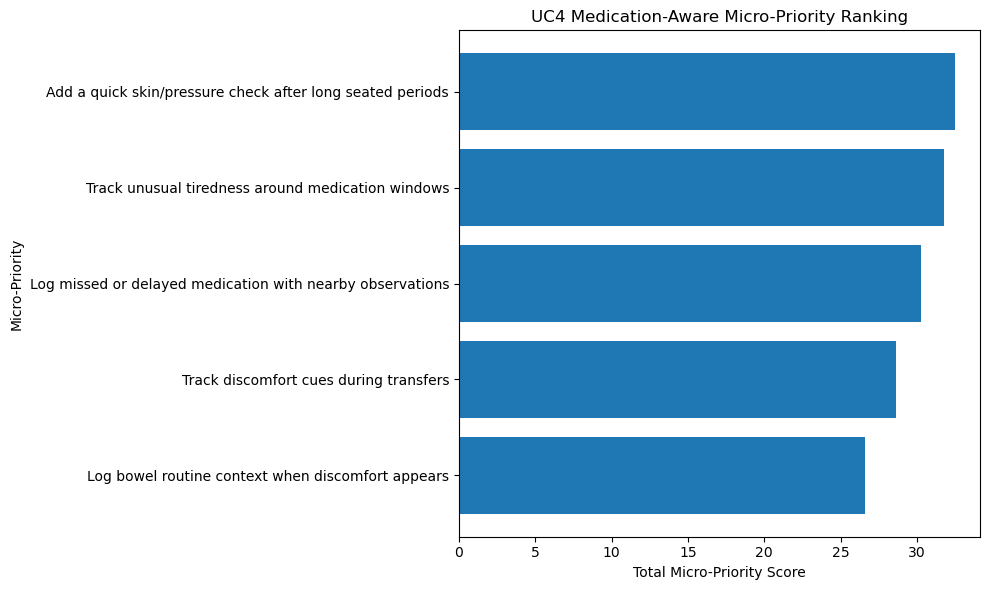

WindowsPath('uc4_medication_aware_micropriority_outputs/figures/micro_priority_ranked_scores.png')

In [55]:
plt.figure(figsize=(10, 6))
plot_df = candidates_df.sort_values("total_micro_priority_score", ascending=True)

plt.barh(plot_df["title"], plot_df["total_micro_priority_score"])
plt.xlabel("Total Micro-Priority Score")
plt.ylabel("Micro-Priority")
plt.title("UC4 Medication-Aware Micro-Priority Ranking")
plt.tight_layout()

fig_path = FIG_DIR / "micro_priority_ranked_scores.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path

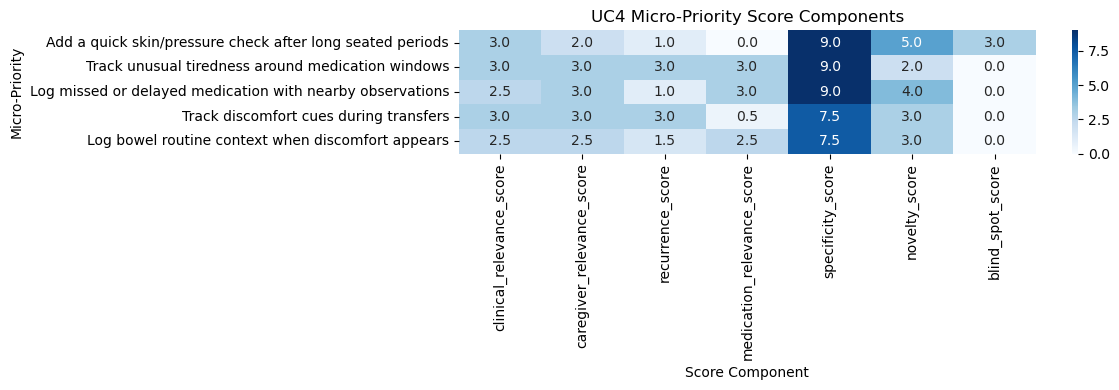

WindowsPath('uc4_medication_aware_micropriority_outputs/figures/micro_priority_score_component_heatmap.png')

In [57]:
score_cols = [
    "clinical_relevance_score",
    "caregiver_relevance_score",
    "recurrence_score",
    "medication_relevance_score",
    "specificity_score",
    "novelty_score",
    "blind_spot_score"
]

heatmap_df = candidates_df.set_index("title")[score_cols]

plt.figure(figsize=(12, max(4, len(heatmap_df) * 0.6)))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", fmt=".1f")
plt.title("UC4 Micro-Priority Score Components")
plt.xlabel("Score Component")
plt.ylabel("Micro-Priority")
plt.tight_layout()

fig_path = FIG_DIR / "micro_priority_score_component_heatmap.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path

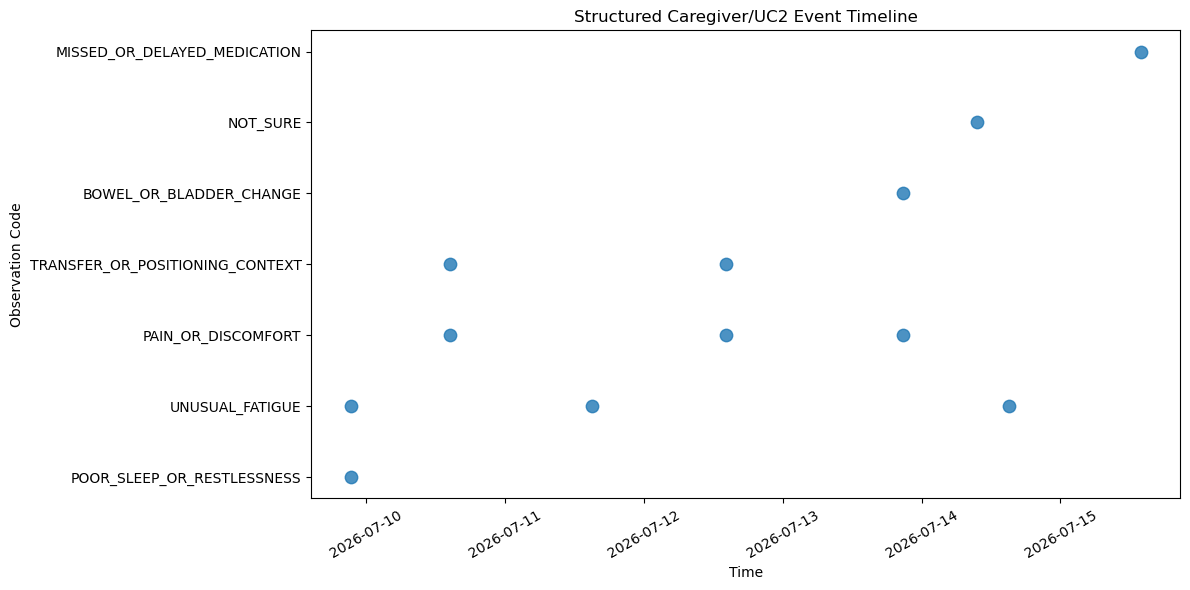

WindowsPath('uc4_medication_aware_micropriority_outputs/figures/structured_event_timeline.png')

In [59]:
timeline_rows = []
for _, row in events_df.iterrows():
    for code in row["observation_codes"]:
        timeline_rows.append({
            "timestamp_dt": row["timestamp_dt"],
            "event_id": row["event_id"],
            "observation_code": code,
            "source_use_case": row["source_use_case"],
            "severity": row["severity"]
        })

timeline_df = pd.DataFrame(timeline_rows)
timeline_df.to_csv(OUTPUT_DIR / "uc4_observation_timeline_long.csv", index=False)

plt.figure(figsize=(12, 6))

codes = timeline_df["observation_code"].unique().tolist()
code_to_y = {code: i for i, code in enumerate(codes)}

plt.scatter(
    timeline_df["timestamp_dt"],
    timeline_df["observation_code"].map(code_to_y),
    s=80,
    alpha=0.8
)

plt.yticks(list(code_to_y.values()), list(code_to_y.keys()))
plt.xlabel("Time")
plt.ylabel("Observation Code")
plt.title("Structured Caregiver/UC2 Event Timeline")
plt.xticks(rotation=30)
plt.tight_layout()

fig_path = FIG_DIR / "structured_event_timeline.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path

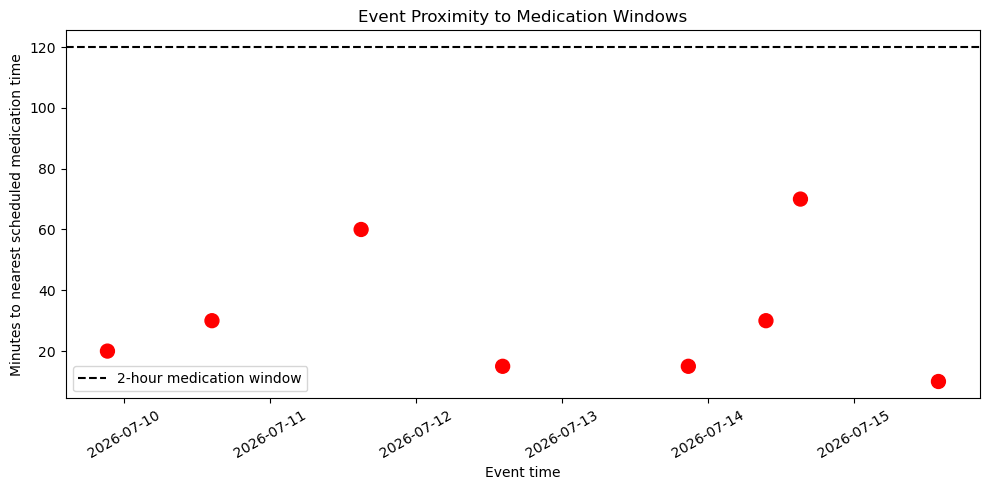

WindowsPath('uc4_medication_aware_micropriority_outputs/figures/event_medication_window_proximity.png')

In [61]:
plt.figure(figsize=(10, 5))
plt.scatter(
    events_df["timestamp_dt"],
    events_df["minutes_to_nearest_med_window"],
    c=events_df["near_med_window"].map({True: "red", False: "gray"}),
    s=100
)
plt.axhline(120, linestyle="--", color="black", label="2-hour medication window")
plt.ylabel("Minutes to nearest scheduled medication time")
plt.xlabel("Event time")
plt.title("Event Proximity to Medication Windows")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "event_medication_window_proximity.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path

In [63]:
app_payload = {
    "uc4_result_type": "ADAPTIVE_CARE_MICRO_PRIORITIES",
    "patient_id": patient_profile["patient_id"],
    "generated_at": anchor_date.isoformat(),
    "top_cards": [
        {
            "rank": p["rank"],
            "title": p["title"],
            "subtitle": p["specific_pattern"],
            "priority_type": p["priority_type"],
            "bullets": p["what_to_log_next"][:3],
            "safety_footer": p["safety_boundary"]
        }
        for p in caregiver_output["top_micro_priorities"]
    ],
    "audit_available": True,
    "free_text_used_for_scoring": False,
    "medication_causality_inferred": False,
    "medication_change_recommended": False
}

with open(OUTPUT_DIR / "uc4_app_payload_preview.json", "w") as f:
    json.dump(app_payload, f, indent=2)

app_payload

{'uc4_result_type': 'ADAPTIVE_CARE_MICRO_PRIORITIES',
 'patient_id': 'Mike_DEMO_001',
 'generated_at': '2026-07-15T18:00:00',
 'top_cards': [{'rank': 1,
   'title': 'Add a quick skin/pressure check after long seated periods',
   'subtitle': 'Low-movement time was higher than baseline, but no skin/pressure checks were logged.',
   'priority_type': 'blind_spot',
   'bullets': ['Long seated period',
    'Skin/pressure check completed',
    'Any concern noted'],
   'safety_footer': 'Care-plan reminder support only; does not detect wounds or diagnose skin issues.'},
  {'rank': 2,
   'title': 'Track unusual tiredness around medication windows',
   'subtitle': 'Unusual fatigue was logged 3 times in the past 7 days.',
   'priority_type': 'medication_aware_watch_area',
   'bullets': ['Approximate time tiredness started',
    'Before/after medication window/not sure',
    'Whether a dose was missed or delayed'],
   'safety_footer': 'This does not mean medication caused the tiredness and does not

In [65]:
for priority in caregiver_output["top_micro_priorities"]:
    print("=" * 100)
    print(priority["caregiver_text"])
    print()

Priority 1: Add a quick skin/pressure check after long seated periods

Why this is on the list:
- Patient profile indicates high mobility support.
- Low-movement hours/day: 9.5. Baseline: 7.0.
- No skin/pressure concern logs were recorded in the past 7 days.

What to watch:
- Redness or discomfort after long seated periods
- Areas under pressure
- Whether usual repositioning schedule changed

What to log next:
- Long seated period
- Skin/pressure check completed
- Any concern noted
- Whether repositioning occurred

When to share or escalate:
Escalate to the care team for persistent redness, skin breakdown, or caregiver concern.

Safety boundary:
Care-plan reminder support only; does not detect wounds or diagnose skin issues.

Priority 2: Track unusual tiredness around medication windows

Why this is on the list:
- Unusual fatigue selected 3 times in 7 days.
- Medication profile includes sleepiness/fatigue as a watch area.
- Medication cause is not inferred.

What to watch:
- Whether ti

In [67]:
manifest = {
    "output_dir": str(OUTPUT_DIR.resolve()),
    "files": [
        "synthetic_patient_profile.json",
        "synthetic_medication_profile.csv",
        "local_medication_watch_area_table.csv",
        "shared_uc_events_structured.csv",
        "synthetic_wearable_weekly_summary.json",
        "previous_week_priorities.csv",
        "uc4_medication_aware_micro_priority_candidates.csv",
        "uc4_top_medication_aware_priorities.csv",
        "uc4_provider_summary.txt",
        "uc4_audit_records.json",
        "uc4_caregiver_output.json",
        "uc4_observation_timeline_long.csv",
        "uc4_app_payload_preview.json",
        "figures/micro_priority_ranked_scores.png",
        "figures/micro_priority_score_component_heatmap.png",
        "figures/structured_event_timeline.png",
        "figures/event_medication_window_proximity.png"
    ],
    "safety": {
        "free_text_used_for_scoring": False,
        "medication_causality_inferred": False,
        "medication_change_recommended": False,
        "diagnosis_generated": False,
        "generation_mode": "rule_based_template"
    }
}

with open(OUTPUT_DIR / "output_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest

{'output_dir': 'C:\\Users\\jaymo\\Desktop\\Desktop\\HTA_Internship\\USE_CASE_4\\uc4_medication_aware_micropriority_outputs',
 'files': ['synthetic_patient_profile.json',
  'synthetic_medication_profile.csv',
  'local_medication_watch_area_table.csv',
  'shared_uc_events_structured.csv',
  'synthetic_wearable_weekly_summary.json',
  'previous_week_priorities.csv',
  'uc4_medication_aware_micro_priority_candidates.csv',
  'uc4_top_medication_aware_priorities.csv',
  'uc4_provider_summary.txt',
  'uc4_audit_records.json',
  'uc4_caregiver_output.json',
  'uc4_observation_timeline_long.csv',
  'uc4_app_payload_preview.json',
  'figures/micro_priority_ranked_scores.png',
  'figures/micro_priority_score_component_heatmap.png',
  'figures/structured_event_timeline.png',
  'figures/event_medication_window_proximity.png'],
 'safety': {'free_text_used_for_scoring': False,
  'medication_causality_inferred': False,
  'medication_change_recommended': False,
  'diagnosis_generated': False,
  'genera